In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    precision_recall_curve,
    auc,
    confusion_matrix,
    classification_report,
    roc_curve
)
import lightgbm as lgb
import xgboost as xgb
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import joblib
import os
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

### Loading Processed Data

In [7]:
X_train = pd.read_csv('data/processed/X_train.csv')
y_train = pd.read_csv('data/processed/y_train.csv').values.ravel()

X_val = pd.read_csv('data/processed/X_val.csv')
y_val = pd.read_csv('data/processed/y_val.csv').values.ravel()

X_test = pd.read_csv('data/processed/X_test.csv')
y_test = pd.read_csv('data/processed/y_test.csv').values.ravel()

print(f"Dataset shapes:")
print(f"  Train: X={X_train.shape}, y={y_train.shape}")
print(f"  Val:   X={X_val.shape},   y={y_val.shape}")
print(f"  Test:  X={X_test.shape},  y={y_test.shape}")

print(f"\nFraud rates:")
print(f"  Train: {y_train.mean()*100:.2f}%")
print(f"  Val:   {y_val.mean()*100:.2f}%")
print(f"  Test:  {y_test.mean()*100:.2f}%")

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"\nClass imbalance ratio (scale_pos_weight): {scale_pos_weight:.2f}")

ERROR! Session/line number was not unique in database. History logging moved to new session 32
Dataset shapes:
  Train: X=(413378, 430), y=(413378,)
  Val:   X=(88581, 430),   y=(88581,)
  Test:  X=(88581, 430),  y=(88581,)

Fraud rates:
  Train: 3.52%
  Val:   3.43%
  Test:  3.48%

Class imbalance ratio (scale_pos_weight): 27.43


### Evaluation Helper Functions

In [8]:
def evaluate_model(y_true, y_pred_proba, model_name="Model", threshold=0.5):
    """Comprehensive model evaluation returning a results dict."""
    y_pred = (y_pred_proba >= threshold).astype(int)

    roc_auc = roc_auc_score(y_true, y_pred_proba)
    precision_arr, recall_arr, _ = precision_recall_curve(y_true, y_pred_proba)
    pr_auc = auc(recall_arr, precision_arr)

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    fpr   = fp / (fp + tn) if (fp + tn) > 0 else 0

    print(f"  {model_name}  (threshold={threshold})")
    print(f"  ROC-AUC : {roc_auc:.4f}    PR-AUC : {pr_auc:.4f}")
    print(f"  Precision: {prec:.4f}    Recall : {rec:.4f}    F1: {f1:.4f}")
    print(f"\n  Confusion Matrix:")
    print(f"              Predicted")
    print(f"              Neg     Pos")
    print(f"  Actual Neg  {tn:>7,}  {fp:>7,}")
    print(f"  Actual Pos  {fn:>7,}  {tp:>7,}")
    print(f"\n  Business:")
    print(f"    Fraud Detection Rate : {rec*100:.2f}%")
    print(f"    False Positive Rate  : {fpr*100:.2f}%")

    return dict(
        model_name=model_name, roc_auc=roc_auc, pr_auc=pr_auc,
        precision=prec, recall=rec, f1=f1,
        fraud_detection_rate=rec, false_positive_rate=fpr,
        threshold=threshold, tn=tn, fp=fp, fn=fn, tp=tp
    )


def plot_curves(models_dict, y_true, title_suffix="Validation"):
    """ROC + PR curves for multiple models."""
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    for name, y_prob in models_dict.items():
        fpr, tpr, _ = roc_curve(y_true, y_prob)
        axes[0].plot(fpr, tpr, label=f'{name} (AUC={roc_auc_score(y_true, y_prob):.3f})', lw=2)
        prec, rec, _ = precision_recall_curve(y_true, y_prob)
        axes[1].plot(rec, prec, label=f'{name} (AUC={auc(rec, prec):.3f})', lw=2)

    axes[0].plot([0,1],[0,1],'k--', label='Random', lw=1.5)
    axes[0].set(xlabel='False Positive Rate', ylabel='True Positive Rate',
                title=f'ROC Curves – {title_suffix}')
    axes[0].legend(loc='lower right')

    baseline = y_true.mean()
    axes[1].axhline(baseline, color='k', linestyle='--', label=f'Baseline ({baseline:.3f})', lw=1.5)
    axes[1].set(xlabel='Recall', ylabel='Precision',
                title=f'Precision-Recall Curves – {title_suffix}')
    axes[1].legend(loc='upper right')

    for ax in axes:
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_confusion_matrices(results_list, y_true_list, labels=None):
    """Side-by-side confusion matrices for a list of result dicts."""
    n = len(results_list)
    fig, axes = plt.subplots(1, n, figsize=(6*n, 5))
    if n == 1:
        axes = [axes]
    for ax, res in zip(axes, results_list):
        cm = np.array([[res['tn'], res['fp']], [res['fn'], res['tp']]])
        sns.heatmap(cm, annot=True, fmt=',d', cmap='Blues', ax=ax,
                    xticklabels=['Legit','Fraud'], yticklabels=['Legit','Fraud'])
        ax.set_title(res['model_name'], fontsize=12, fontweight='bold')
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    plt.tight_layout()
    plt.show()

### Baseline Model 1 – Logistic Regression

In [9]:
lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
    n_jobs=-1
)
lr_model.fit(X_train, y_train)

y_val_pred_lr = lr_model.predict_proba(X_val)[:, 1]
lr_results = evaluate_model(y_val, y_val_pred_lr, "Logistic Regression")

  Logistic Regression  (threshold=0.5)
  ROC-AUC : 0.7683    PR-AUC : 0.1773
  Precision: 0.0756    Recall : 0.6831    F1: 0.1362

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   60,145   25,394
  Actual Pos      964    2,078

  Business:
    Fraud Detection Rate : 68.31%
    False Positive Rate  : 29.69%


### Baseline Model 2 – Random Forest

In [10]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=20,
    min_samples_leaf=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

y_val_pred_rf = rf_model.predict_proba(X_val)[:, 1]
rf_results = evaluate_model(y_val, y_val_pred_rf, "Random Forest")

  Random Forest  (threshold=0.5)
  ROC-AUC : 0.9104    PR-AUC : 0.5250
  Precision: 0.2240    Recall : 0.7459    F1: 0.3445

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   77,677    7,862
  Actual Pos      773    2,269

  Business:
    Fraud Detection Rate : 74.59%
    False Positive Rate  : 9.19%


### Advanced Model 1 – XGBoost (Default Parameters)

In [12]:
xgb_default = xgb.XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    eval_metric='auc',
    early_stopping_rounds=50
)
xgb_default.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_val_pred_xgb = xgb_default.predict_proba(X_val)[:, 1]
xgb_default_results = evaluate_model(y_val, y_val_pred_xgb, "XGBoost (Default)")

  XGBoost (Default)  (threshold=0.5)
  ROC-AUC : 0.9476    PR-AUC : 0.6460
  Precision: 0.2932    Recall : 0.7867    F1: 0.4272

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   79,770    5,769
  Actual Pos      649    2,393

  Business:
    Fraud Detection Rate : 78.67%
    False Positive Rate  : 6.74%


### Advanced Model 2 – LightGBM (Default Parameters)

In [13]:
lgbm_default = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm_default.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

y_val_pred_lgbm = lgbm_default.predict_proba(X_val)[:, 1]
lgbm_default_results = evaluate_model(y_val, y_val_pred_lgbm, "LightGBM (Default)")

  LightGBM (Default)  (threshold=0.5)
  ROC-AUC : 0.8921    PR-AUC : 0.3761
  Precision: 0.0000    Recall : 0.0000    F1: 0.0000

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   85,539        0
  Actual Pos    3,042        0

  Business:
    Fraud Detection Rate : 0.00%
    False Positive Rate  : 0.00%


### Comparing Baseline vs Default Advanced Models

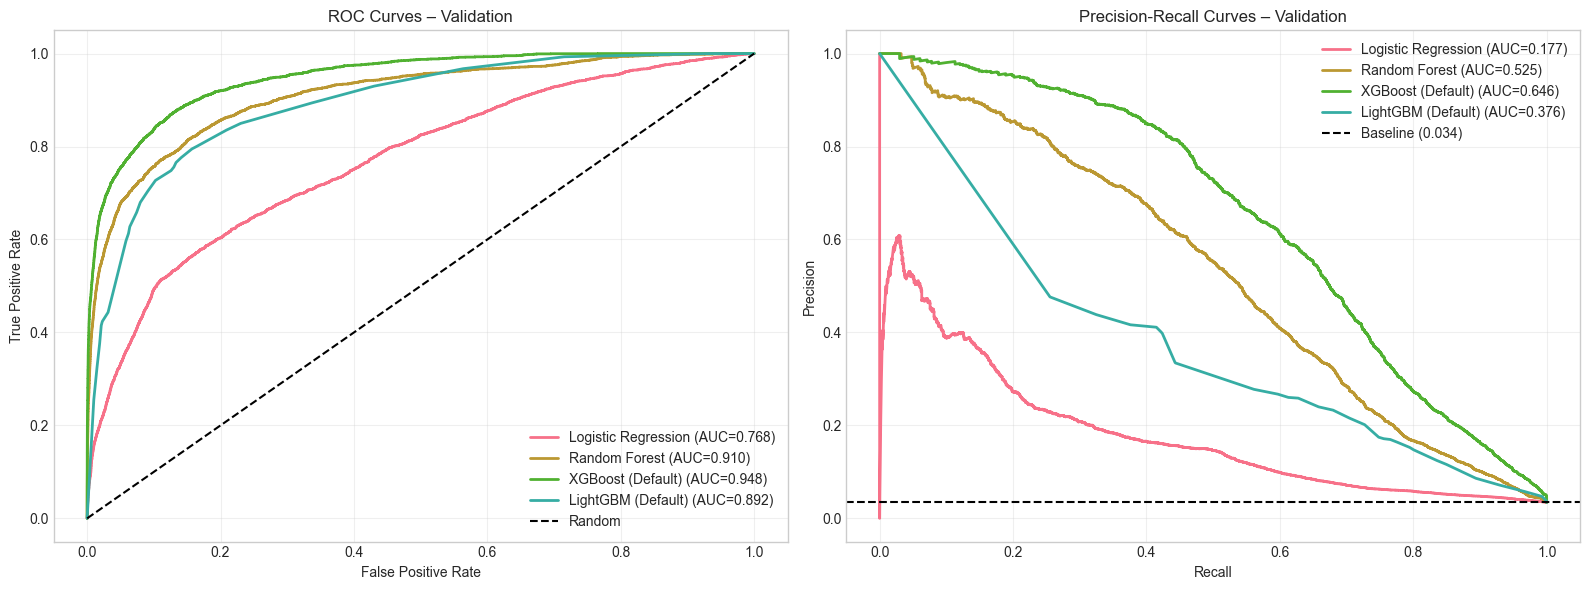

In [14]:
models_val = {
    "Logistic Regression" : y_val_pred_lr,
    "Random Forest"       : y_val_pred_rf,
    "XGBoost (Default)"   : y_val_pred_xgb,
    "LightGBM (Default)"  : y_val_pred_lgbm
}
plot_curves(models_val, y_val)

### Hyperparameter Tuning – XGBoost (Optuna, 50 trials)

In [15]:
def objective_xgb(trial):
    params = {
        'objective' : 'binary:logistic',
        'eval_metric' : 'auc',
        'scale_pos_weight' : scale_pos_weight,
        'random_state' : 42,
        'n_jobs' : -1,
        'n_estimators' : trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate' : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth' : trial.suggest_int('max_depth', 3, 12),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'subsample' : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma' : trial.suggest_float('gamma', 1e-8, 1.0, log=True),
        'reg_alpha' : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda' : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = xgb.XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)
    y_prob = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    return auc(rec, prec)

study_xgb = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
)
study_xgb.optimize(objective_xgb, n_trials=50, show_progress_bar=True)

print(f"\nBest XGBoost PR-AUC : {study_xgb.best_value:.4f}")
print("Best parameters:")
for k, v in study_xgb.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost PR-AUC : 0.7080
Best parameters:
  n_estimators: 935
  learning_rate: 0.06607226524093766
  max_depth: 11
  min_child_weight: 9
  subsample: 0.8168431608333798
  colsample_bytree: 0.6223936918123186
  gamma: 0.012050315522249614
  reg_alpha: 0.0015132938490975668
  reg_lambda: 5.011050579902147e-07


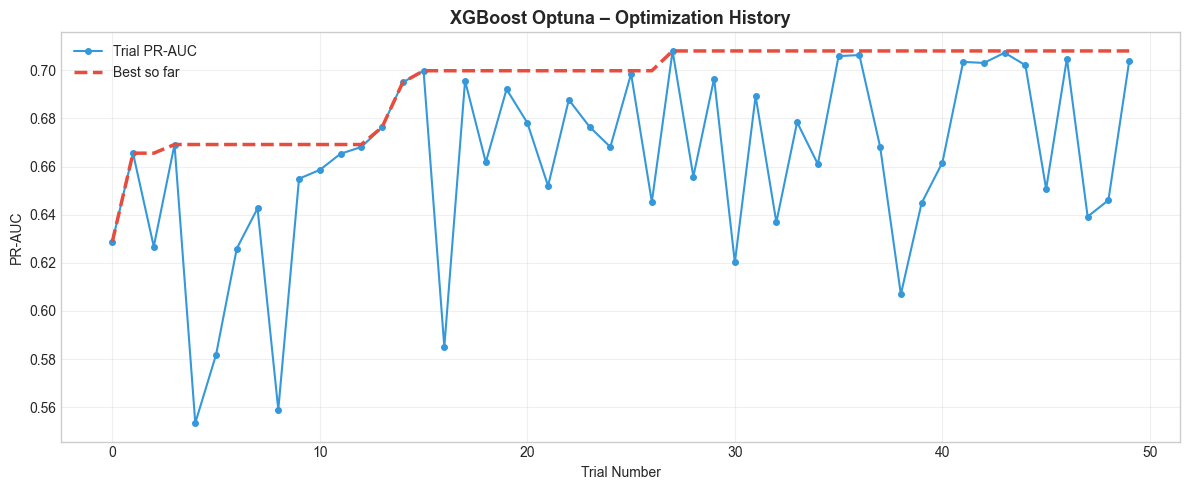

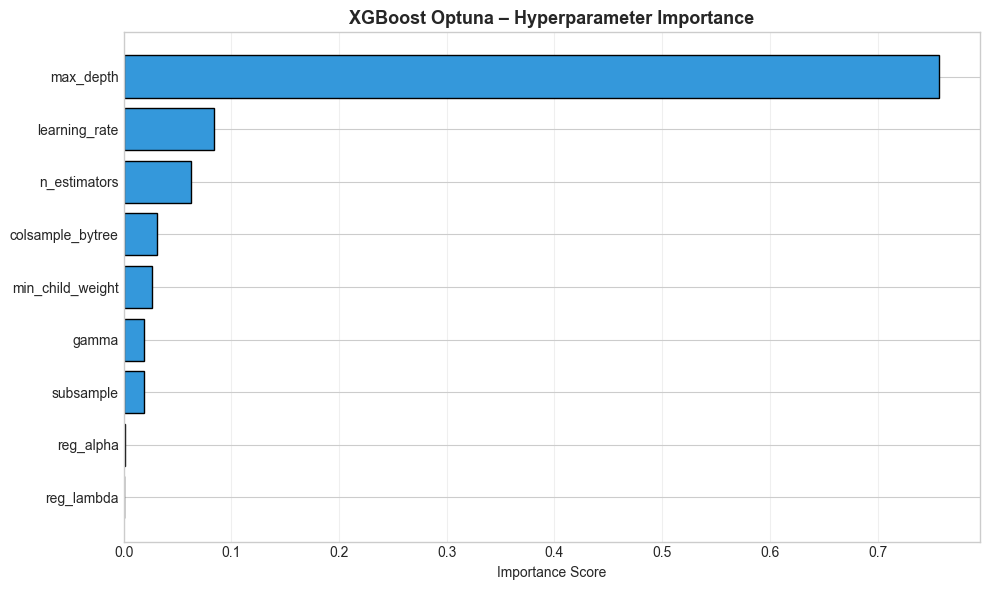

In [16]:
# Optimization History
trials_df = study_xgb.trials_dataframe()

plt.figure(figsize=(12, 5))
plt.plot(trials_df['number'], trials_df['value'], marker='o', markersize=4,
         linewidth=1.5, color='#3498db', label='Trial PR-AUC')
best_so_far = trials_df['value'].cummax()
plt.plot(trials_df['number'], best_so_far, linewidth=2.5,
         color='#e74c3c', linestyle='--', label='Best so far')
plt.xlabel('Trial Number'); plt.ylabel('PR-AUC')
plt.title('XGBoost Optuna – Optimization History', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Hyperparameter Importance
importances = optuna.importance.get_param_importances(study_xgb)
params = list(importances.keys())
values = list(importances.values())

plt.figure(figsize=(10, 6))
bars = plt.barh(params[::-1], values[::-1], color='#3498db', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('XGBoost Optuna – Hyperparameter Importance', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

### Hyperparameter Tuning – LightGBM (Optuna, 50 trials)

In [18]:
def objective_lgbm(trial):
    params = {
        'objective'        : 'binary',
        'metric'           : 'auc',
        'scale_pos_weight' : scale_pos_weight,
        'random_state'     : 42,
        'n_jobs'           : -1,
        'verbose'          : -1,
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves'       : trial.suggest_int('num_leaves', 20, 150),
        'max_depth'        : trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
    }
    model = lgb.LGBMClassifier(**params)
    model.fit(
        X_train, y_train,
        eval_set=[(X_val, y_val)],
        eval_metric='auc',
        callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
    )
    y_prob = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, y_prob)
    return auc(rec, prec)

study_lgbm = optuna.create_study(
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_startup_trials=10, n_warmup_steps=20)
)
study_lgbm.optimize(objective_lgbm, n_trials=50, show_progress_bar=True)

print(f"\nBest LightGBM PR-AUC : {study_lgbm.best_value:.4f}")
print("Best parameters:")
for k, v in study_lgbm.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM PR-AUC : 0.6865
Best parameters:
  n_estimators: 581
  learning_rate: 0.24304138853655385
  num_leaves: 133
  max_depth: 12
  min_child_samples: 83
  subsample: 0.6755400835592231
  colsample_bytree: 0.738875872479262
  reg_alpha: 3.436837071725214e-06
  reg_lambda: 2.0614050388789655


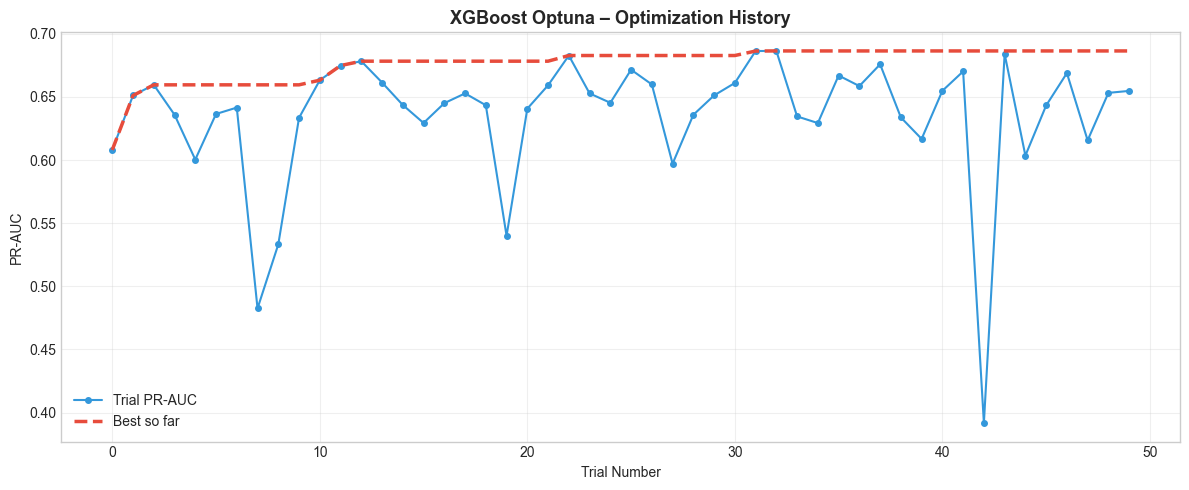

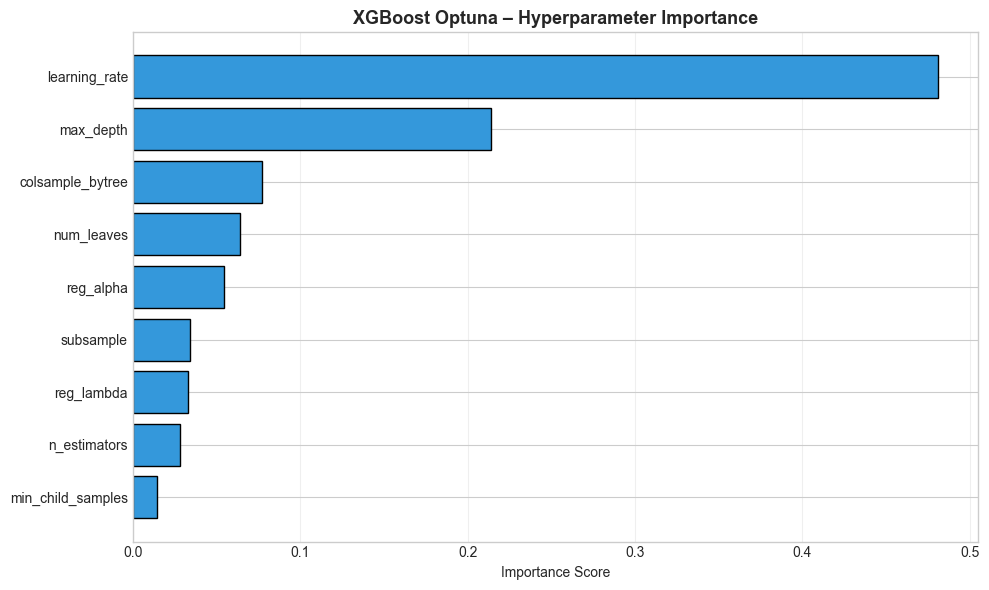

In [19]:
# Optimization History
trials_df = study_lgbm.trials_dataframe()

plt.figure(figsize=(12, 5))
plt.plot(trials_df['number'], trials_df['value'], marker='o', markersize=4,
         linewidth=1.5, color='#3498db', label='Trial PR-AUC')
best_so_far = trials_df['value'].cummax()
plt.plot(trials_df['number'], best_so_far, linewidth=2.5,
         color='#e74c3c', linestyle='--', label='Best so far')
plt.xlabel('Trial Number'); plt.ylabel('PR-AUC')
plt.title('XGBoost Optuna – Optimization History', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

# Hyperparameter Importance
importances = optuna.importance.get_param_importances(study_lgbm)
params = list(importances.keys())
values = list(importances.values())

plt.figure(figsize=(10, 6))
bars = plt.barh(params[::-1], values[::-1], color='#3498db', edgecolor='black')
plt.xlabel('Importance Score')
plt.title('XGBoost Optuna – Hyperparameter Importance', fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='x'); plt.tight_layout(); plt.show()

### Retraining Best Tuned Models

In [20]:
# Best XGBoost
best_xgb_params = {
    **study_xgb.best_params,
    'objective' : 'binary:logistic',
    'eval_metric' : 'auc',
    'scale_pos_weight' : scale_pos_weight,
    'random_state' : 42,
    'n_jobs' : -1,
    'early_stopping_rounds': 50
}
xgb_tuned = xgb.XGBClassifier(**best_xgb_params)
xgb_tuned.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

y_val_pred_xgb_tuned = xgb_tuned.predict_proba(X_val)[:, 1]
xgb_tuned_results = evaluate_model(y_val, y_val_pred_xgb_tuned, "XGBoost (Tuned)")

# Best LightGBM
best_lgbm_params = {
    **study_lgbm.best_params,
    'objective'        : 'binary',
    'metric'           : 'auc',
    'scale_pos_weight' : scale_pos_weight,
    'random_state'     : 42,
    'n_jobs'           : -1,
    'verbose'          : -1
}
lgbm_tuned = lgb.LGBMClassifier(**best_lgbm_params)
lgbm_tuned.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    eval_metric='auc',
    callbacks=[lgb.early_stopping(50, verbose=False), lgb.log_evaluation(-1)]
)

y_val_pred_lgbm_tuned = lgbm_tuned.predict_proba(X_val)[:, 1]
lgbm_tuned_results = evaluate_model(y_val, y_val_pred_lgbm_tuned, "LightGBM (Tuned)")

  XGBoost (Tuned)  (threshold=0.5)
  ROC-AUC : 0.9502    PR-AUC : 0.7080
  Precision: 0.8057    Recall : 0.5710    F1: 0.6683

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   85,120      419
  Actual Pos    1,305    1,737

  Business:
    Fraud Detection Rate : 57.10%
    False Positive Rate  : 0.49%
  LightGBM (Tuned)  (threshold=0.5)
  ROC-AUC : 0.9391    PR-AUC : 0.6865
  Precision: 0.7720    Recall : 0.5631    F1: 0.6512

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   85,033      506
  Actual Pos    1,329    1,713

  Business:
    Fraud Detection Rate : 56.31%
    False Positive Rate  : 0.59%


### Full Model Comparison on Validation Set

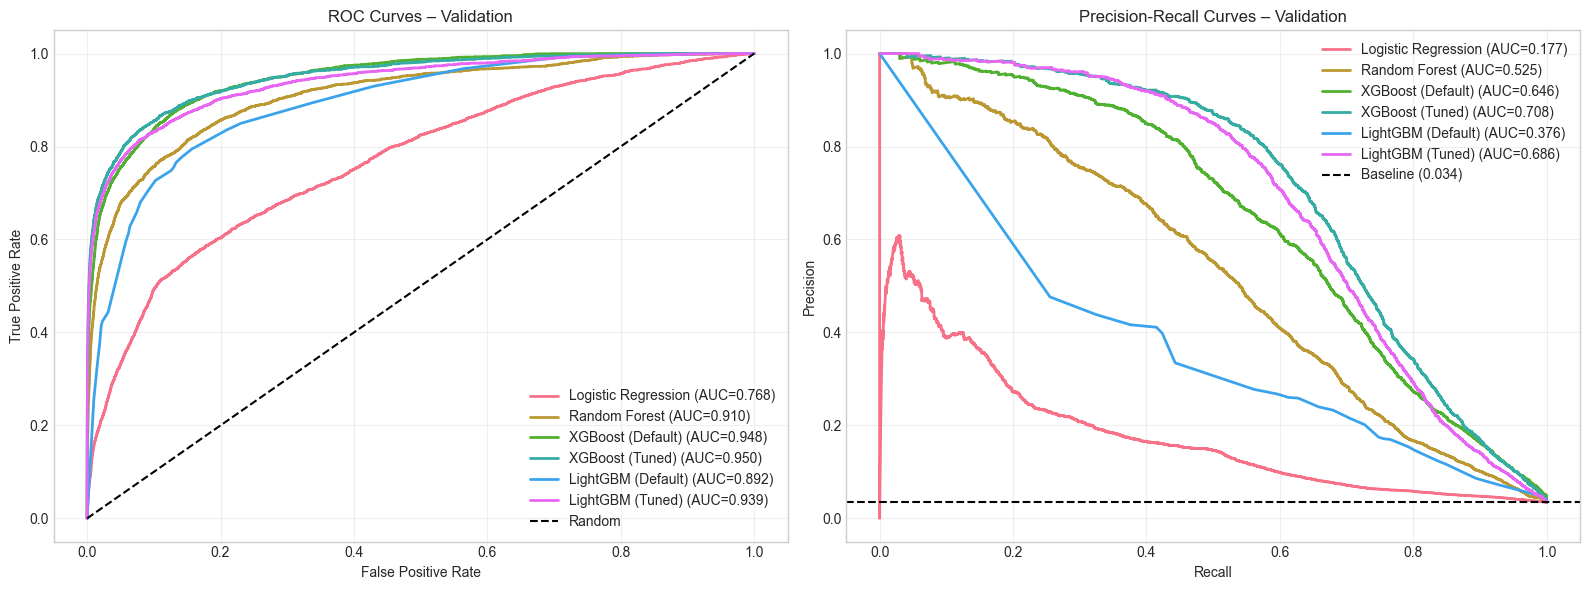


Model Comparison (Validation Set):
              Model  ROC-AUC  PR-AUC  Precision  Recall     F1  FPR (%)
Logistic Regression   0.7683  0.1773     0.0756  0.6831 0.1362    29.69
      Random Forest   0.9104  0.5250     0.2240  0.7459 0.3445     9.19
  XGBoost (Default)   0.9476  0.6460     0.2932  0.7867 0.4272     6.74
    XGBoost (Tuned)   0.9502  0.7080     0.8057  0.5710 0.6683     0.49
 LightGBM (Default)   0.8921  0.3761     0.0000  0.0000 0.0000     0.00
   LightGBM (Tuned)   0.9391  0.6865     0.7720  0.5631 0.6512     0.59


In [24]:
all_val_preds = {
    "Logistic Regression" : y_val_pred_lr,
    "Random Forest"       : y_val_pred_rf,
    "XGBoost (Default)"   : y_val_pred_xgb,
    "XGBoost (Tuned)"     : y_val_pred_xgb_tuned,
    "LightGBM (Default)"  : y_val_pred_lgbm,
    "LightGBM (Tuned)"    : y_val_pred_lgbm_tuned
}
plot_curves(all_val_preds, y_val)

# Summary table
all_results = [lr_results, rf_results, xgb_default_results, xgb_tuned_results,
               lgbm_default_results, lgbm_tuned_results]
summary = pd.DataFrame([{
    'Model'               : r['model_name'],
    'ROC-AUC'             : round(r['roc_auc'], 4),
    'PR-AUC'              : round(r['pr_auc'], 4),
    'Precision'           : round(r['precision'], 4),
    'Recall'              : round(r['recall'], 4),
    'F1'                  : round(r['f1'], 4),
    'FPR (%)'             : round(r['false_positive_rate']*100, 2)
} for r in all_results])

print("\nModel Comparison (Validation Set):")
print(summary.to_string(index=False))

### Threshold Optimisation for Best Model

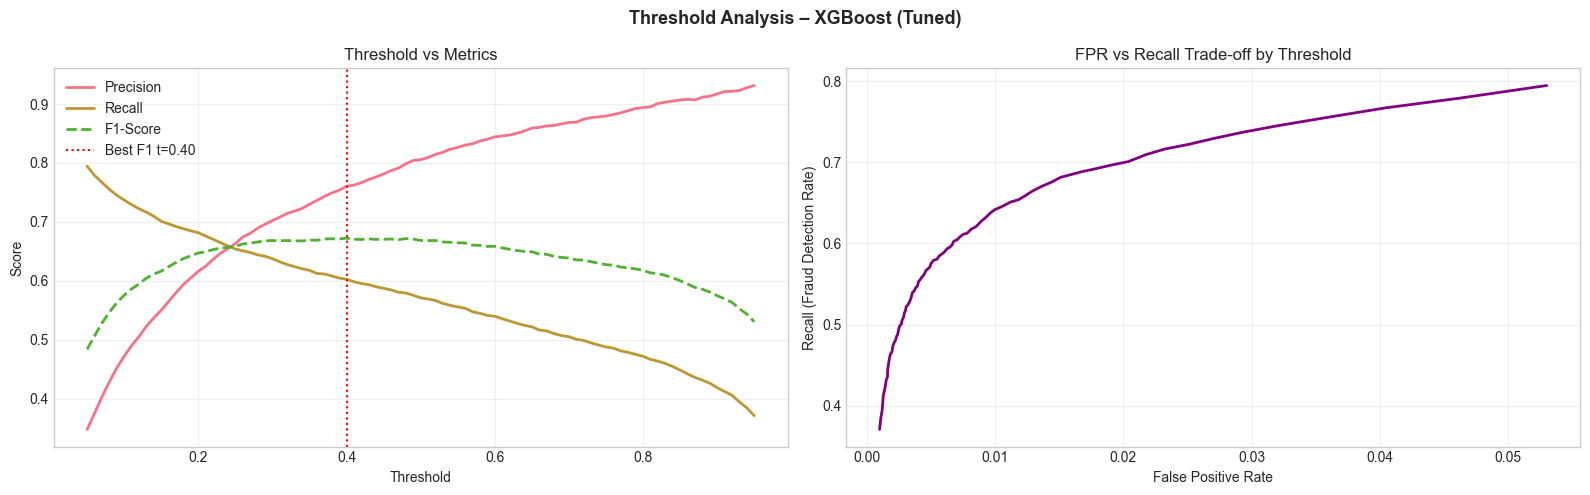

Optimal threshold (max F1): 0.40
  Precision: 0.7603
  Recall: 0.6026
  F1: 0.6723
  FPR: 0.0068


In [33]:
best_val_preds = y_val_pred_xgb_tuned
best_model_name = "XGBoost (Tuned)"

thresholds = np.arange(0.05, 0.96, 0.01)
results_thresh = []

for t in thresholds:
    y_pred = (best_val_preds >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_val, y_pred).ravel()
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    fpr = fp / (fp + tn)
    results_thresh.append(dict(threshold=t, precision=prec, recall=rec, f1=f1, fpr=fpr))

thresh_df = pd.DataFrame(results_thresh)

# Plot
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(thresh_df['threshold'], thresh_df['precision'], label='Precision', lw=2)
axes[0].plot(thresh_df['threshold'], thresh_df['recall'],    label='Recall',    lw=2)
axes[0].plot(thresh_df['threshold'], thresh_df['f1'],        label='F1-Score',  lw=2, linestyle='--')
best_f1_row = thresh_df.loc[thresh_df['f1'].idxmax()]
axes[0].axvline(best_f1_row['threshold'], color='red', linestyle=':', label=f"Best F1 t={best_f1_row['threshold']:.2f}")
axes[0].set(xlabel='Threshold', ylabel='Score', title='Threshold vs Metrics')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(thresh_df['fpr'], thresh_df['recall'], lw=2, color='purple')
axes[1].set(xlabel='False Positive Rate', ylabel='Recall (Fraud Detection Rate)',
            title='FPR vs Recall Trade-off by Threshold')
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Threshold Analysis – {best_model_name}', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

optimal_threshold = best_f1_row['threshold']
print(f"Optimal threshold (max F1): {optimal_threshold:.2f}")
print(f"  Precision: {best_f1_row['precision']:.4f}")
print(f"  Recall: {best_f1_row['recall']:.4f}")
print(f"  F1: {best_f1_row['f1']:.4f}")
print(f"  FPR: {best_f1_row['fpr']:.4f}")

### Feature Importance – Tuned Models

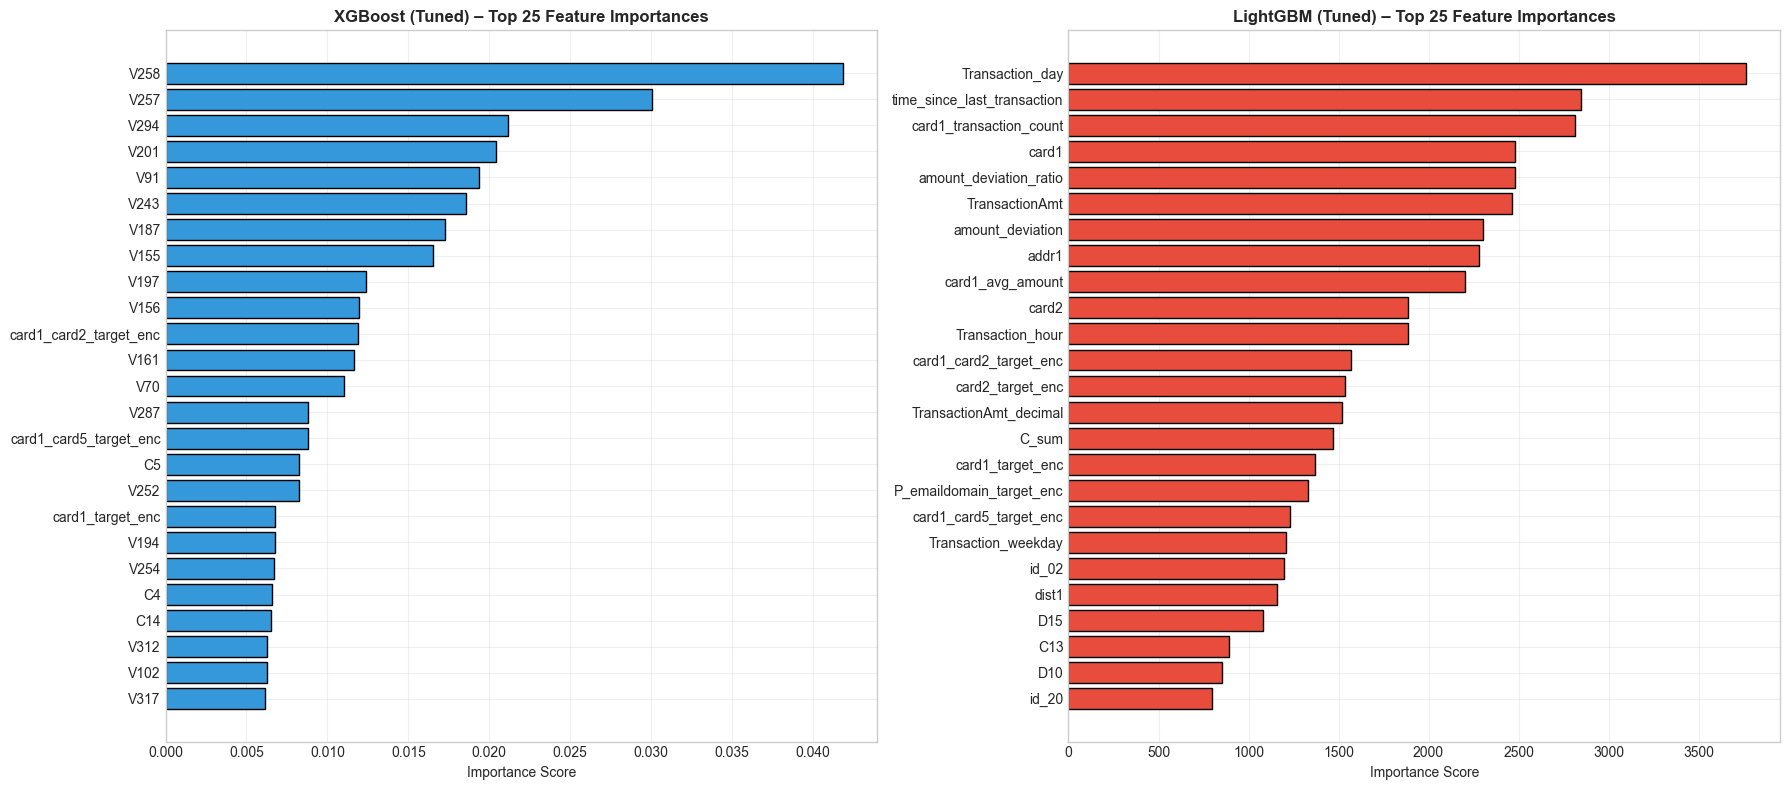


Top-15 features in common across both models (1):
  card1_card2_target_enc


In [34]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# XGBoost
xgb_imp = pd.Series(xgb_tuned.feature_importances_, index=X_train.columns)
xgb_imp = xgb_imp.sort_values(ascending=False).head(25)
axes[0].barh(xgb_imp.index[::-1], xgb_imp.values[::-1], color='#3498db', edgecolor='black')
axes[0].set_title('XGBoost (Tuned) – Top 25 Feature Importances', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Importance Score')
axes[0].grid(True, alpha=0.3)

# LightGBM
lgbm_imp = pd.Series(lgbm_tuned.feature_importances_, index=X_train.columns)
lgbm_imp = lgbm_imp.sort_values(ascending=False).head(25)
axes[1].barh(lgbm_imp.index[::-1], lgbm_imp.values[::-1], color='#e74c3c', edgecolor='black')
axes[1].set_title('LightGBM (Tuned) – Top 25 Feature Importances', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Importance Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Agreement between models
top_xgb  = set(xgb_imp.head(15).index)
top_lgbm = set(lgbm_imp.head(15).index)
common   = top_xgb & top_lgbm
print(f"\nTop-15 features in common across both models ({len(common)}):")
for f in sorted(common):
    print(f"  {f}")

### Final Evaluation on Held-Out Test Set

  XGBoost (Tuned)  (threshold=0.4000000000000001)
  ROC-AUC : 0.9285    PR-AUC : 0.6165
  Precision: 0.6755    Recall : 0.5319    F1: 0.5952

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   84,710      788
  Actual Pos    1,443    1,640

  Business:
    Fraud Detection Rate : 53.19%
    False Positive Rate  : 0.92%
  LightGBM (Tuned)  (threshold=0.4000000000000001)
  ROC-AUC : 0.9158    PR-AUC : 0.5851
  Precision: 0.6434    Recall : 0.5180    F1: 0.5739

  Confusion Matrix:
              Predicted
              Neg     Pos
  Actual Neg   84,613      885
  Actual Pos    1,486    1,597

  Business:
    Fraud Detection Rate : 51.80%
    False Positive Rate  : 1.04%


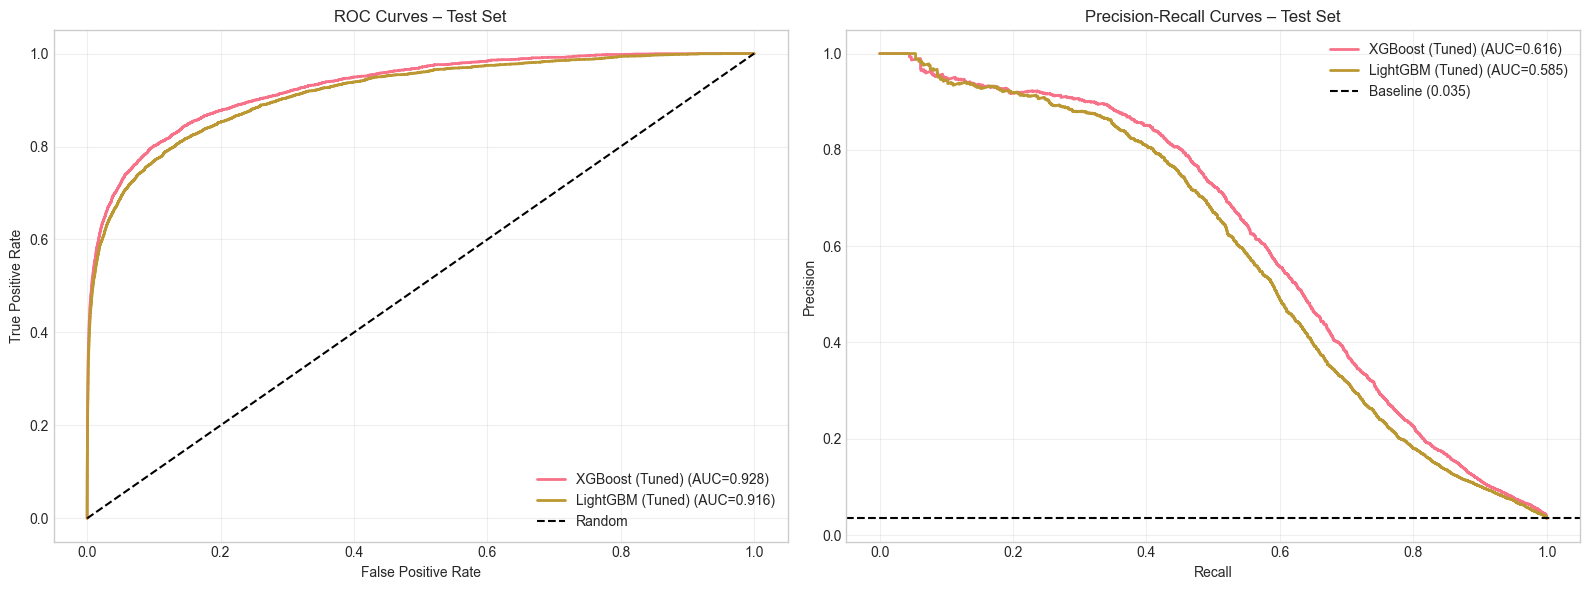

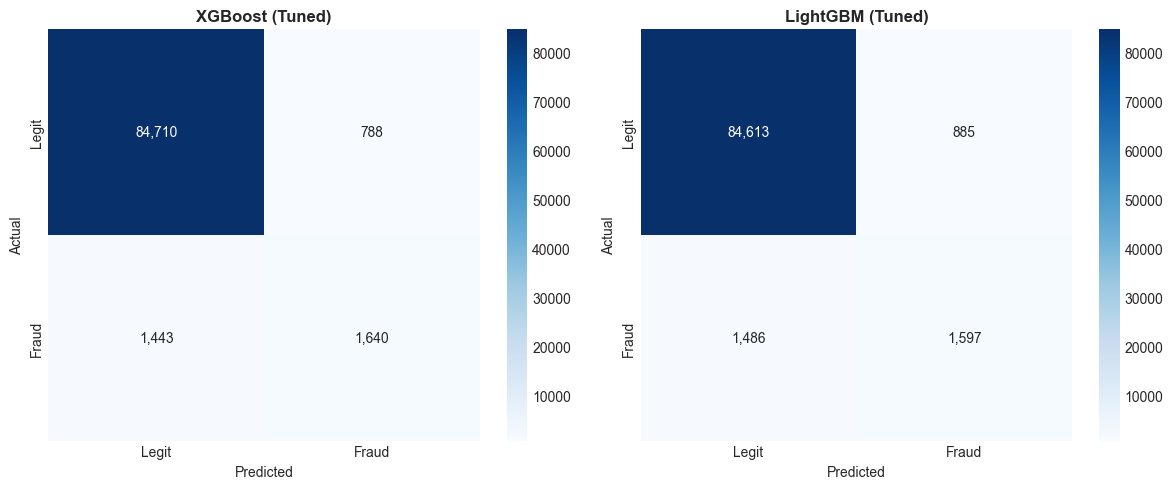

In [36]:
# Selecting champion model (XGBoost Tuned)
champion_model      = xgb_tuned
champion_name       = "XGBoost (Tuned)"
champion_threshold  = optimal_threshold

y_test_pred = champion_model.predict_proba(X_test)[:, 1]
test_results = evaluate_model(y_test, y_test_pred, champion_name, threshold=champion_threshold)

# Also evaluate tuned LightGBM on test for reference
y_test_pred_lgbm = lgbm_tuned.predict_proba(X_test)[:, 1]
lgbm_test_results = evaluate_model(y_test, y_test_pred_lgbm, "LightGBM (Tuned)", threshold=champion_threshold)

plot_curves(
    {champion_name: y_test_pred, "LightGBM (Tuned)": y_test_pred_lgbm},
    y_test,
    title_suffix="Test Set"
)
plot_confusion_matrices([test_results, lgbm_test_results], [y_test, y_test])

### Business Cost Analysis

We attach monetary costs to each error type:
- **False Negative (missed fraud)**: Full transaction value is lost  
- **False Positive (wrong block)**: Customer friction cost (estimated at \$5 flat)

Sweeping thresholds to minimise expected cost.

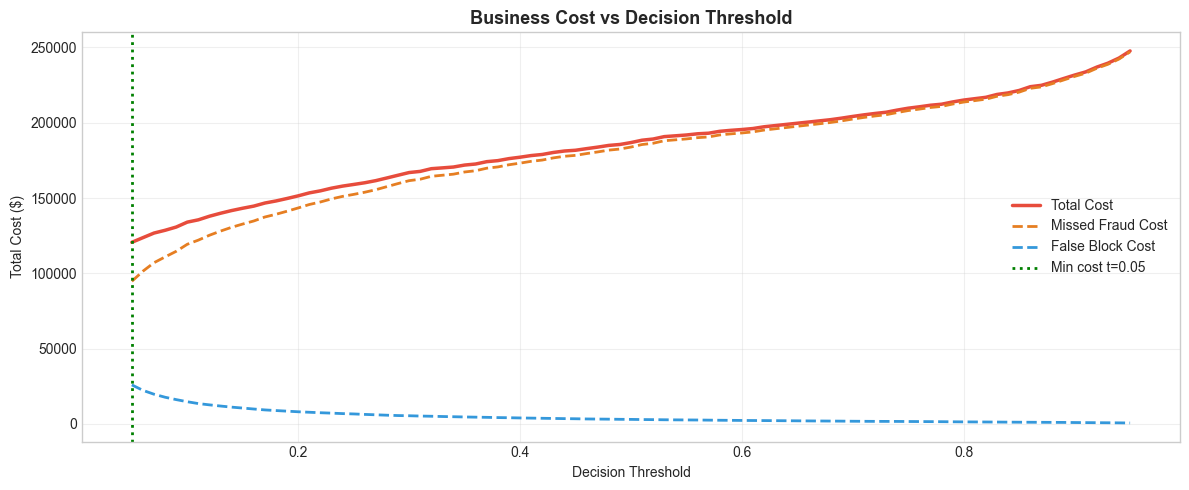

Cost-optimal threshold : 0.05
Total cost : $120,580
Missed-fraud cost : $94,680
False-block cost : $25,900


In [37]:
# Configurable cost parameters
avg_fraud_amt = 120.0 # average fraud transaction value ($)
false_positive_cost =  5.0 # customer friction cost per wrong block ($)

thresholds_cost = np.arange(0.05, 0.96, 0.01)
costs = []

for t in thresholds_cost:
    y_pred = (y_test_pred >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    total_cost = fn * avg_fraud_amt + fp * false_positive_cost
    costs.append(dict(threshold=t, total_cost=total_cost, fn_cost=fn*avg_fraud_amt, fp_cost=fp*false_positive_cost))

cost_df = pd.DataFrame(costs)
best_cost_row = cost_df.loc[cost_df['total_cost'].idxmin()]

plt.figure(figsize=(12, 5))
plt.plot(cost_df['threshold'], cost_df['total_cost'],  label='Total Cost',      lw=2.5, color='#e74c3c')
plt.plot(cost_df['threshold'], cost_df['fn_cost'],     label='Missed Fraud Cost',lw=2, linestyle='--', color='#e67e22')
plt.plot(cost_df['threshold'], cost_df['fp_cost'],     label='False Block Cost', lw=2, linestyle='--', color='#3498db')
plt.axvline(best_cost_row['threshold'], color='green', linestyle=':', lw=2,
            label=f"Min cost t={best_cost_row['threshold']:.2f}")
plt.xlabel('Decision Threshold'); plt.ylabel('Total Cost ($)')
plt.title('Business Cost vs Decision Threshold', fontsize=13, fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3); plt.tight_layout(); plt.show()

print(f"Cost-optimal threshold : {best_cost_row['threshold']:.2f}")
print(f"Total cost : ${best_cost_row['total_cost']:,.0f}")
print(f"Missed-fraud cost : ${best_cost_row['fn_cost']:,.0f}")
print(f"False-block cost : ${best_cost_row['fp_cost']:,.0f}")

### Saving Models

In [38]:
os.makedirs('models', exist_ok=True)

joblib.dump(lr_model,'models/lr_model.pkl')
joblib.dump(rf_model,'models/rf_model.pkl')
joblib.dump(xgb_default,'models/xgb_default.pkl')
joblib.dump(xgb_tuned,'models/xgb_tuned.pkl')
joblib.dump(lgbm_default,'models/lgbm_default.pkl')
joblib.dump(lgbm_tuned,'models/lgbm_tuned.pkl')

# Saving champion metadata
import json
meta = {
    'champion_model' : champion_name,
    'optimal_threshold' : float(optimal_threshold),
    'cost_optimal_threshold': float(best_cost_row['threshold']),
    'val_roc_auc' : lgbm_tuned_results['roc_auc'],
    'val_pr_auc' : lgbm_tuned_results['pr_auc'],
    'test_roc_auc' : test_results['roc_auc'],
    'test_pr_auc' : test_results['pr_auc']
}
with open('models/champion_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print("Saved models:")
for fname in os.listdir('models'):
    size = os.path.getsize(f'models/{fname}')
    print(f"  {fname:<35} ({size/1024:.1f} KB)")

Saved models:
  lgbm_default.pkl                    (16.6 KB)
  lr_model.pkl                        (7.7 KB)
  rf_model.pkl                        (6550.0 KB)
  champion_meta.json                  (0.3 KB)
  xgb_tuned.pkl                       (14394.3 KB)
  lgbm_tuned.pkl                      (7720.2 KB)
  xgb_default.pkl                     (1928.7 KB)


### Summary & Next Steps

In [39]:
print("Modeling & Evaluation Summary")
print(f"\nModels trained: Logistic Regression, Random Forest,")
print(f"XGBoost (default + Optuna-tuned),")
print(f"LightGBM (default + Optuna-tuned)")
print(f"\nTuning: 50 Optuna trials each, optimising PR-AUC")
print(f"\nChampion : {champion_name}")
print(f"Test ROC-AUC : {test_results['roc_auc']:.4f}")
print(f"Test PR-AUC : {test_results['pr_auc']:.4f}")
print(f"Test Recall : {test_results['recall']*100:.2f}%  (fraud detection rate)")
print(f"Test FPR : {test_results['false_positive_rate']*100:.2f}%")
print(f"\nThresholds saved:")
print(f"F1-optimal : {optimal_threshold:.2f}")
print(f"Cost-optimal : {best_cost_row['threshold']:.2f}")
print(f"\nNext step: A/B testing (04_ab_testing.ipynb)")

Modeling & Evaluation Summary

Models trained: Logistic Regression, Random Forest,
XGBoost (default + Optuna-tuned),
LightGBM (default + Optuna-tuned)

Tuning: 50 Optuna trials each, optimising PR-AUC

Champion : XGBoost (Tuned)
Test ROC-AUC : 0.9285
Test PR-AUC : 0.6165
Test Recall : 53.19%  (fraud detection rate)
Test FPR : 0.92%

Thresholds saved:
F1-optimal : 0.40
Cost-optimal : 0.05

Next step: A/B testing (04_ab_testing.ipynb)
